In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from dask_jobqueue import PBSCluster
from dask.distributed import Client
import numpy as np
import cartopy.crs as ccrs

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
cluster = PBSCluster(
    cores=1,
    memory='32GB',
    processes=1,
    queue='casper',
    local_directory='$TMPDIR',
    account='P93300313',
    walltime='2:00:00'
)
cluster.scale(jobs=5)
client = Client(cluster)
client

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40987 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/40987/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/40987/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.185:43063,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/40987/status,Total threads: 0
Started: Just now,Total memory: 0 B


# import data

In [5]:
Q = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/Q/cropped_Q_1940.nc')
Q

<xarray.Dataset> Size: 349MB
Dimensions:    (time: 8784, latitude: 82, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 70kB 1940-01-01 ... 1940-12-31T23:00:00
  * latitude   (latitude) float64 656B 28.0 27.75 27.5 27.25 ... 8.25 8.0 7.75
  * longitude  (longitude) float64 968B 271.0 271.2 271.5 ... 300.5 300.8 301.0
    level      float64 8B ...
Data variables:
    Q          (time, latitude, longitude) float32 349MB ...

In [7]:
Q['Q'].isel(time=3).values

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(82, 121), dtype=float32)

In [4]:
U = xr.open_zarr('/glade/work/acruz/Caribbean_Heat_data/ERA5/U10')
V = xr.open_zarr('/glade/work/acruz/Caribbean_Heat_data/ERA5/V10')

In [5]:
years = np.arange(1940, 2026, 1)
U = U.sel(time=U.time.dt.year.isin(years))
V = V.sel(time=V.time.dt.year.isin(years))

In [6]:
U

<xarray.Dataset> Size: 30GB
Dimensions:    (time: 753888, latitude: 82, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:00:00
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    VAR_10U    (time, latitude, longitude) float32 30GB dask.array<chunksize=(62824, 82, 121), meta=np.ndarray>

In [7]:
V

<xarray.Dataset> Size: 30GB
Dimensions:    (time: 753888, latitude: 82, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:00:00
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    VAR_10V    (time, latitude, longitude) float32 30GB dask.array<chunksize=(62824, 82, 121), meta=np.ndarray>

# flux

In [8]:
def q_flux(q, u, v):
    qu = q * u
    qv = q * v
    ds = xr.Dataset({'Q_U': qu, 'Q_V': qv})
    return ds

In [9]:
Qflux_ds = q_flux(Q['Q'], U['VAR_10U'], V['VAR_10V']).drop_vars('level')
Qflux_ds

<xarray.Dataset> Size: 60GB
Dimensions:    (latitude: 82, longitude: 121, time: 753888)
Coordinates:
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:00:00
Data variables:
    Q_U        (time, latitude, longitude) float32 30GB dask.array<chunksize=(62824, 82, 121), meta=np.ndarray>
    Q_V        (time, latitude, longitude) float32 30GB dask.array<chunksize=(62824, 82, 121), meta=np.ndarray>

# divergence

In [10]:
def xr_div(u_da, v_ds):
    # spherical divergencce
    # first term goes to 0 due to surface
    R = 6371000
    deg2rad = np.pi / 180
    cos_phi = np.cos(np.deg2rad(Qflux_ds.latitude))

    da_du = u_da.differentiate(coord='longitude')
    
    v_ds_cos_phi = v_ds * cos_phi
    da_dv = v_ds_cos_phi.differentiate(coord='latitude')
    
    div = (da_du + da_dv) / (R * cos_phi * deg2rad) 
    return div.rename('field_divergence').astype('float32')

In [11]:
MFD = xr_div(Qflux_ds['Q_U'], Qflux_ds['Q_V'])
MFD

<xarray.DataArray 'field_divergence' (time: 753888, latitude: 82, longitude: 121)> Size: 30GB
dask.array<astype, shape=(753888, 82, 121), dtype=float32, chunksize=(62824, 82, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:00:00
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Attributes:
    long_name:   latitude
    short_name:  lat
    units:       degrees_north

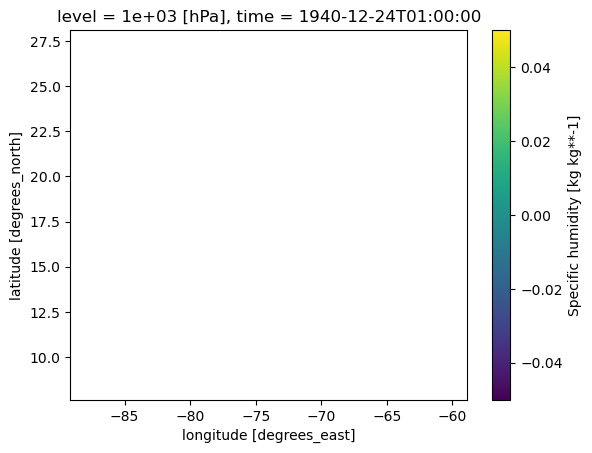

In [20]:
Q['Q'].isel(time=8593).plot()

In [29]:
MFD.to_netcdf('/glade/work/acruz/Caribbean_Heat_data/ERA5/MFD.nc', mode='w')

In [30]:
client.shutdown()